<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_04_Deep_Learning/Week_02_Back_Propogation/Day_05_Early_Stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from matplotlib.colors import ListedColormap

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
x, y = make_circles(n_samples = 200, shuffle=True, noise = 0.2, random_state= 1)

<Axes: >

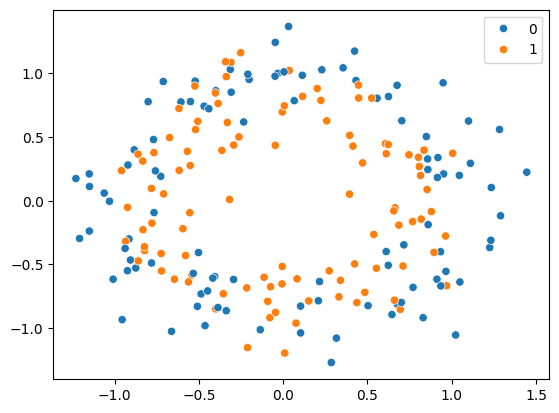

In [31]:
sns.scatterplot(x=x[:,0], y=x[:,1], hue= y)

In [17]:
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)


In [18]:
model = Sequential()

In [19]:
model.add(Dense(256, activation='relu', input_dim = 2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2000, verbose=0)

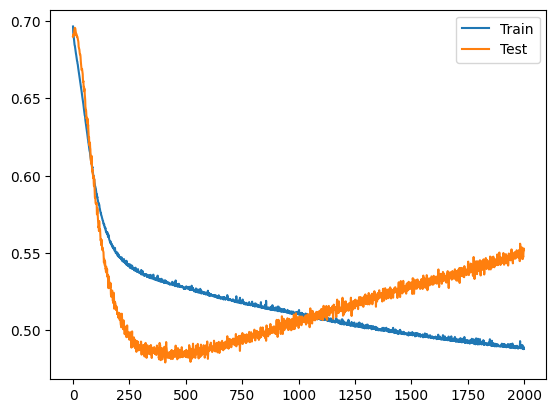

In [22]:
plt.plot(history.history['loss'], label = 'Train')
plt.plot(history.history['val_loss'], label = 'Test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


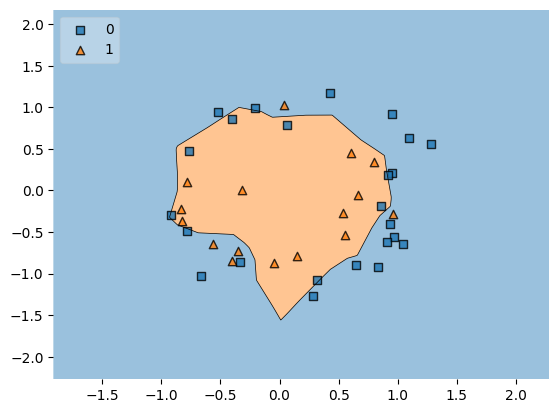

In [23]:
plot_decision_regions(x_test, y_test.ravel(), clf = model, legend = 2)
plt.show()

### EARLY STOPPING - case

In [24]:
model = Sequential()

In [25]:
model.add(Dense(256, activation='relu', input_dim = 2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [32]:
Call_back = EarlyStopping(
    monitor = 'val_loss',
    verbose = 1,
    patience = 20,
    min_delta = 0.00001,
    mode = 'auto',
    restore_best_weights = True,
    baseline = None
)

In [33]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2000, callbacks= Call_back)

Epoch 1/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4476 - loss: 0.6948 - val_accuracy: 0.5500 - val_loss: 0.6886
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5028 - loss: 0.6906 - val_accuracy: 0.6000 - val_loss: 0.6880
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5623 - loss: 0.6885 - val_accuracy: 0.5250 - val_loss: 0.6909
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5726 - loss: 0.6886 - val_accuracy: 0.4500 - val_loss: 0.6927
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6456 - loss: 0.6839 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 6/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6317 - loss: 0.6835 - val_accuracy: 0.4750 - val_loss: 0.6933
Epoch 7/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6394 - loss: 0.6827 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 8/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6454 - loss: 0.6812 - val_accuracy: 0.5000 - v

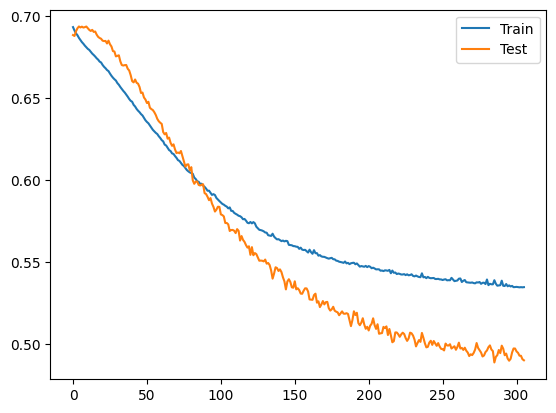

In [34]:
plt.plot(history.history['loss'], label = 'Train')
plt.plot(history.history['val_loss'], label = 'Test')
plt.legend()
plt.show()

and that's all for Early stopping,
you can use it for reducing the effect for overfitting!
next will be about Normalization process to improve ANN